# 04. Deep Agents 서브에이전트 (Subagents)

> **왜 서브에이전트가 필요한가요?**
>
> 한 사람이 모든 일을 다 하면 비효율적이에요. 회사에서도 리서치는 리서치팀, 개발은 개발팀, 문서는 기술문서팀이 맡듯이, 에이전트도 **전문 분야별로 나누면** 각자의 역할에 집중해서 더 정확한 결과를 만들어요.

> 🔑 **비유**: 서브에이전트는 **프로젝트 팀**과 같아요. 메인 에이전트(PM)가 전체를 조율하고, 리서처·분석가·작성가가 각자 전문 분야를 맡아요. PM은 직접 코딩하지 않고, 적재적소에 팀원을 배치해요.

## 학습 목표

이 노트북을 마치면 다음을 할 수 있어요:

1. SubAgent 딕셔너리와 `CompiledSubAgent` 두 가지 방식으로 서브에이전트를 정의할 수 있어요
2. `general-purpose` 서브에이전트의 자동 포함 규칙과 오버라이드 방법을 이해할 수 있어요
3. `config.context`를 통한 컨텍스트 전파(Propagation) 패턴을 구현할 수 있어요
4. `AsyncSubAgent`로 서브에이전트를 비동기로 실행하고 결과를 취합할 수 있어요

## 사전 지식

- 이전 노트북 `03-Context-Engineering.ipynb`: 5가지 컨텍스트 타입
- `create_deep_agent` 기본 사용법 (`01-Deep-Agents-Overview.ipynb`)
- LangGraph `StateGraph` 컴파일 패턴 (Part 2에서 학습)

## 서브에이전트 아키텍처

Deep Agents에서 서브에이전트는 **메인 에이전트가 특정 작업을 위임하는 전문 에이전트**예요. 메인 에이전트가 `task` 도구를 호출하면, 내부적으로 지정된 서브에이전트가 해당 작업을 처리하고 결과를 반환해요.

```mermaid
flowchart TD
    USER["사용자 요청<br>복잡한 다단계 작업"] --> MAIN["메인 에이전트<br>create_deep_agent"]

    subgraph SUBAGENTS["서브에이전트 풀 (subagents=)"]
        SA1["SubAgent dict<br>이름+설명+도구"]
        SA2["CompiledSubAgent<br>기존 LangGraph 그래프"]
        SA3["general-purpose<br>자동 포함 (기본값)"]
    end

    MAIN -->|"task 도구 호출<br>어느 에이전트에게?"| SUBAGENTS
    SA1 -->|"결과 반환"| MAIN
    SA2 -->|"결과 반환"| MAIN
    SA3 -->|"결과 반환"| MAIN
    MAIN --> OUTPUT["통합 결과 반환"]

    classDef user fill:#d4edda,stroke:#28a745,color:#155724
    classDef main fill:#e2d5f1,stroke:#6f42c1,color:#3d1f6e
    classDef sub fill:#cce5ff,stroke:#007bff,color:#004085
    classDef output fill:#fff3cd,stroke:#ffc107,color:#856404

    class USER user
    class MAIN main
    class SA1,SA2,SA3 sub
    class OUTPUT output
```

### 서브에이전트 정의 방식 비교

| 방식 | 형태 | 특징 | 추천 시나리오 |
|------|------|------|---------------|
| **딕셔너리(dict)** | `{"name": ..., "description": ..., "tools": [...]}` | 빠른 정의, 선언적 | 새로운 전문 에이전트 생성 |
| **CompiledSubAgent** | `CompiledSubAgent(name=..., runnable=compiled_graph)` | 기존 그래프 재활용 | Part 2~9에서 만든 그래프 재사용 |
| **general-purpose** | `subagents=None` (기본값) | 자동 포함, 부모 상속 | 간단한 보조 작업 |

> 🔑 **핵심 개념**: `subagents=None`(기본값)일 때 Deep Agents는 **general-purpose 서브에이전트**를 자동으로 포함시켜요. 이 에이전트는 부모의 모델·도구·스킬을 상속받아요. `subagents=[]`로 명시하면 서브에이전트를 완전히 비활성화할 수 있어요.

## 환경 설정

In [1]:
# ---------------------------------------------------
# 환경 변수 로드
# ---------------------------------------------------
# .env 파일에서 OPENAI_API_KEY 등을 로드해요
from dotenv import load_dotenv
load_dotenv()

True

In [2]:
# ---------------------------------------------------
# LangSmith 추적 설정 (선택 사항)
# ---------------------------------------------------
import os
# os.environ["LANGCHAIN_TRACING_V2"] = "true"
# os.environ["LANGCHAIN_PROJECT"] = "LangGraph-Deep-Agents-Subagents"

In [3]:
# ---------------------------------------------------
# deepagents 패키지 임포트
# ---------------------------------------------------
import deepagents
from deepagents import create_deep_agent

print(f"deepagents 버전: {deepagents.__version__}")


deepagents 버전: 0.5.3


## 1. SubAgent 딕셔너리 방식

서브에이전트를 가장 빠르게 정의하는 방법은 딕셔너리(dict)를 사용하는 것이에요. 공식 [Subagents 문서](https://docs.langchain.com/oss/python/deepagents/subagents) 기준 필드는 다음과 같아요.

### SubAgent dict 필드

| 필드 | 필수 여부 | 타입 | 설명 |
|------|----------|------|------|
| `name` | 필수 | `str` | 서브에이전트 고유 식별자 (영문 소문자·하이픈 권장) |
| `description` | 필수 | `str` | 메인 에이전트가 라우팅에 참고하는 역할 설명 |
| `system_prompt` | 필수 | `str` | 서브에이전트 전용 시스템 프롬프트 (부모 프롬프트 상속 없음) |
| `tools` | 선택 | `list` | 서브에이전트가 사용할 도구. 지정하면 부모 tools를 완전히 대체해요 |
| `model` | 선택 | `str` / `BaseChatModel` | 모델 오버라이드. 생략하면 부모 모델 상속 |
| `middleware` | 선택 | `list` | 서브에이전트 전용 미들웨어 |
| `interrupt_on` | 선택 | `dict` | 서브에이전트 내 HITL 도구 설정 |
| `skills` | 선택 | `list[str]` | 서브에이전트 전용 스킬 디렉토리 |
| `response_format` | 선택 | `ResponseFormat` | 구조화 출력 스키마 |

> ⚠️ **자주 하는 실수**: `system_prompt`는 **필수**예요. 서브에이전트는 부모 프롬프트를 상속하지 않으므로, 프롬프트를 누락하면 서브에이전트가 자기 역할을 인식하지 못해요. 반면 `tools`는 선택 필드로, **지정 시 부모 tools를 완전히 덮어써요**(공식 문서: *"overrides parent when specified"*).

> 💡 **실무 팁**: `description`은 메인 에이전트가 작업 라우팅을 결정할 때 참고해요. "어떤 작업을 이 에이전트에게 줘야 하나요?"에 명확히 답하도록 구체적으로 작성하세요. "당신은 X 전문가입니다. Y, Z 유형의 작업을 담당합니다"처럼 작성하면 라우팅 정확도가 높아져요.

In [ ]:
# ---------------------------------------------------
# 서브에이전트용 도구 정의
# ---------------------------------------------------
# 각 서브에이전트에 특화된 도구를 먼저 만들어요
from langchain.tools import tool


@tool
def web_search(query: str) -> str:
    """웹에서 정보를 검색해요.

    Args:
        query: 검색할 질문 또는 키워드
    """
    # 실습용 모의(mock) 결과예요.
    # 실제로는 Tavily, DuckDuckGo API 등을 호출해요.
    # 강의 맥락을 유지하기 위해 공식 문서 기반의 고정 지식을 반환해요.
    if "langgraph" in query.lower():
        return (
            "LangGraph V1 핵심 자료:\n"
            "- LangGraph는 장기 실행 상태 기반 에이전트를 위한 orchestration framework/runtime입니다.\n"
            "- StateGraph로 상태와 노드를 명시하고, compile 후 invoke/stream API로 실행합니다.\n"
            "- durable execution, streaming, human-in-the-loop, memory가 핵심 운영 기능입니다.\n"
            "- Deep Agents는 LangGraph 위에서 planning, filesystem, subagents 등을 묶어 제공하는 harness입니다."
        )
    if "deep agents" in query.lower() or "deepagents" in query.lower():
        return (
            "Deep Agents 핵심 자료:\n"
            "- 복잡한 multi-step agent 작업을 위한 LangGraph 기반 harness입니다.\n"
            "- planning 도구, virtual filesystem/backend, subagents, context management, code execution, HITL을 제공합니다.\n"
            "- skills와 memory는 필요한 지식과 절차를 점진적으로 불러오는 컨텍스트 관리 기능입니다."
        )
    return (
        f"'{query}' 검색 결과:\n"
        f"- 공식 문서 2건 발견\n"
        f"- 예제 코드 3건 발견\n"
        f"(모의 검색 결과 — 실제 환경에서는 Tavily API 사용)"
    )


@tool
def analyze_data(data: str, analysis_type: str = "summary") -> str:
    """데이터를 분석하고 인사이트를 도출해요.

    Args:
        data: 분석할 데이터 문자열
        analysis_type: 분석 유형 ('summary', 'trend', 'comparison')
    """
    # 데이터 분석 도구 (모의 구현)
    return (
        f"[{analysis_type.upper()} 분석 결과]\n"
        f"입력 요약: {data[:180]}...\n"
        f"핵심 인사이트:\n"
        f"1. LangGraph는 일반 NLP 도구가 아니라 상태 기반 에이전트 오케스트레이션 런타임입니다.\n"
        f"2. Deep Agents는 LangGraph 위에 planning/filesystem/subagents/HITL을 얹은 harness입니다.\n"
        f"3. 보고서에는 두 계층의 역할 차이를 분리해서 설명해야 합니다."
    )


@tool
def format_report(content: str, format_type: str = "markdown") -> str:
    """보고서를 지정한 형식으로 포맷해요.

    Args:
        content: 포맷할 내용
        format_type: 형식 ('markdown', 'html', 'plain')
    """
    # 보고서 포맷 도구 (모의 구현)
    if format_type == "markdown":
        return f"# 보고서\n\n{content}\n\n---\n*자동 생성된 보고서*"
    return f"보고서:\n{content}"


# 서브에이전트용 도구 정의 완료:
print(f"  - web_search: 웹 검색")
print(f"  - analyze_data: 데이터 분석")
print(f"  - format_report: 보고서 포맷")


In [5]:
# ---------------------------------------------------
# SubAgent 딕셔너리 정의
# ---------------------------------------------------
# 각 딕셔너리는 전문 서브에이전트 1개를 정의해요

# 리서처 서브에이전트: 정보 수집 전문
researcher_subagent = {
    "name": "researcher",           # 식별자 (task 도구가 이 이름으로 호출해요)
    "description": (                # 메인 에이전트가 참고하는 역할 설명
        "웹 검색과 자료 수집 전문가입니다. "
        "특정 주제에 대한 정보 검색, 논문·블로그·공식 문서 수집, "
        "검색 결과 정리 작업을 담당해요."
    ),
    "model": "openai:gpt-4o-mini",  # 서브에이전트 전용 모델 (선택)
    "tools": [web_search],          # 선택: 지정 시 부모 tools를 대체해요
    "system_prompt": (              # 필수: 서브에이전트는 부모 프롬프트를 상속하지 않아요
        "당신은 정보 수집 전문가입니다. "
        "web_search 도구를 활용해 요청된 주제를 철저히 조사하고 "
        "핵심 내용을 명확하게 요약해서 반환하세요."
    ),
}

# 분석가 서브에이전트: 데이터 분석 전문
analyst_subagent = {
    "name": "analyst",
    "description": (
        "데이터 분석 전문가입니다. "
        "수집된 데이터에서 패턴 발견, 트렌드 분석, "
        "인사이트 도출 작업을 담당해요."
    ),
    "model": "openai:gpt-4o-mini",
    "tools": [analyze_data],
    "system_prompt": (
        "당신은 데이터 분석 전문가입니다. "
        "analyze_data 도구로 데이터를 분석하고 "
        "핵심 인사이트를 구조적으로 정리해서 반환하세요."
    ),
}

# 작성가 서브에이전트: 보고서 작성 전문
writer_subagent = {
    "name": "writer",
    "description": (
        "보고서 작성 전문가입니다. "
        "분석 결과를 바탕으로 구조적인 보고서 작성, "
        "마크다운 포맷 변환 작업을 담당해요."
    ),
    "model": "openai:gpt-4o-mini",
    "tools": [format_report],
    "system_prompt": (
        "당신은 보고서 작성 전문가입니다. "
        "format_report 도구로 최종 보고서를 작성하고 "
        "명확하고 읽기 좋은 형태로 완성해주세요."
    ),
}

# ---------------------------------------------------
# 정의된 서브에이전트 목록 출력
# ---------------------------------------------------
subagent_list = [researcher_subagent, analyst_subagent, writer_subagent]

# SubAgent 딕셔너리 정의 완료:
# ------------------------------------------------------------
for sa in subagent_list:
    print(f"  이름: {sa['name']}")
    print(f"  설명: {sa['description'][:50]}...")
    print(f"  도구: {[t.name for t in sa['tools']]}")
    print()

  이름: researcher
  설명: 웹 검색과 자료 수집 전문가입니다. 특정 주제에 대한 정보 검색, 논문·블로그·공식 문서 ...
  도구: ['web_search']

  이름: analyst
  설명: 데이터 분석 전문가입니다. 수집된 데이터에서 패턴 발견, 트렌드 분석, 인사이트 도출 작업...
  도구: ['analyze_data']

  이름: writer
  설명: 보고서 작성 전문가입니다. 분석 결과를 바탕으로 구조적인 보고서 작성, 마크다운 포맷 변환...
  도구: ['format_report']



## 2. CompiledSubAgent — 기존 LangGraph 그래프 재활용

`CompiledSubAgent`는 Part 2~9에서 이미 만들어둔 LangGraph 그래프를 서브에이전트로 재활용할 수 있는 방법이에요. 기존 코드 자산을 버리지 않고 Deep Agents 생태계에 통합할 수 있어요.

```mermaid
flowchart LR
    subgraph EXISTING["기존 코드 자산"]
        G1["Part 2 챗봇 그래프"]
        G2["Part 8 RAG 그래프"]
        G3["커스텀 분석 그래프"]
    end

    subgraph WRAP["CompiledSubAgent 래핑"]
        W1["CompiledSubAgent<br>name='chatbot'"]
        W2["CompiledSubAgent<br>name='rag-agent'"]
        W3["CompiledSubAgent<br>name='analyzer'"]
    end

    MAIN["메인 에이전트<br>create_deep_agent"]

    G1 --> W1
    G2 --> W2
    G3 --> W3
    W1 --> MAIN
    W2 --> MAIN
    W3 --> MAIN

    classDef existing fill:#d4edda,stroke:#28a745,color:#155724
    classDef wrap fill:#cce5ff,stroke:#007bff,color:#004085
    classDef main fill:#e2d5f1,stroke:#6f42c1,color:#3d1f6e

    class G1,G2,G3 existing
    class W1,W2,W3 wrap
    class MAIN main
```

> 🎯 **강의 포인트**: `CompiledSubAgent`의 핵심 가치는 **기존 투자 보호**예요. 학생들에게 "Part 8에서 만든 RAG 그래프 기억나요? 그걸 `CompiledSubAgent`로 감싸면 Deep Agents의 서브에이전트로 즉시 사용할 수 있어요"라고 강조해주세요.

In [6]:
# ---------------------------------------------------
# CompiledSubAgent 사용 예시
# ---------------------------------------------------
# 먼저 간단한 LangGraph 그래프를 만들어요 (기존 코드 자산 역할)
from typing import TypedDict, Annotated
from langchain.messages import HumanMessage, AIMessage
from langchain.chat_models import init_chat_model
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages


# ---------------------------------------------------
# 기존 LangGraph 그래프 정의 (Part 2 스타일)
# ---------------------------------------------------
class AnalyzerState(TypedDict):
    """분석 에이전트의 상태 타입이에요."""
    messages: Annotated[list, add_messages]  # 메시지 리스트 (add_messages 리듀서)


# 모델 초기화 (gpt-4o-mini 기본값)
analyzer_model = init_chat_model("openai:gpt-4o-mini")


def analyze_node(state: AnalyzerState) -> dict:
    """데이터 분석 노드예요. 입력 메시지를 분석해서 응답을 생성해요."""
    # 시스템 프롬프트를 포함해서 모델을 호출해요
    from langchain.messages import SystemMessage

    system = SystemMessage(
        content=(
            "당신은 정량 데이터 분석 전문가입니다. "
            "입력된 텍스트에서 수치 데이터를 추출하고 "
            "통계적 인사이트를 제공하세요."
        )
    )
    # 시스템 메시지 + 대화 히스토리로 모델 호출
    response = analyzer_model.invoke([system] + state["messages"])
    return {"messages": [response]}


# 그래프 구성 및 컴파일
analyzer_graph = StateGraph(AnalyzerState)
analyzer_graph.add_node("analyze", analyze_node)  # 분석 노드 추가
analyzer_graph.add_edge(START, "analyze")          # 시작 → 분석
analyzer_graph.add_edge("analyze", END)            # 분석 → 종료

# 컴파일된 그래프 생성
compiled_analyzer = analyzer_graph.compile()
print(f"기존 그래프 컴파일 완료: {type(compiled_analyzer).__name__}")

# ---------------------------------------------------
# CompiledSubAgent로 기존 그래프 래핑
# ---------------------------------------------------
from deepagents import CompiledSubAgent

# 기존 컴파일된 그래프를 서브에이전트로 래핑해요
# CompiledSubAgent는 TypedDict 형태예요 → 딕셔너리처럼 접근해요
analyzer_compiled_subagent = CompiledSubAgent(
    name="data-analyzer",                    # 서브에이전트 식별자
    description=(
        "정량 데이터 분석 전문가입니다. "
        "수치 데이터 추출, 통계 분석, 패턴 발견 작업을 담당해요. "
        "기존 LangGraph 그래프로 동작해요."
    ),
    runnable=compiled_analyzer,                 # 컴파일된 LangGraph 그래프
)
# TypedDict이므로 딕셔너리 키로 접근해요
print(f"CompiledSubAgent 생성 완료: {analyzer_compiled_subagent['name']}")


기존 그래프 컴파일 완료: CompiledStateGraph
CompiledSubAgent 생성 완료: data-analyzer


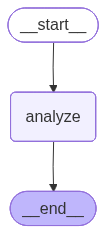

In [7]:
# 그래프 흐름: START → analyze → END
# analyze: 입력 메시지를 분석하여 정량 데이터 인사이트를 제공하는 노드예요
# 이 그래프는 CompiledSubAgent로 래핑되어 Deep Agents의 서브에이전트로 재활용돼요
from IPython.display import Image, display

display(Image(compiled_analyzer.get_graph().draw_mermaid_png()))

## 3. general-purpose 서브에이전트

`subagents` 파라미터를 생략(기본값 `None`)하면, Deep Agents는 **general-purpose** 서브에이전트를 자동으로 포함시켜요. 이 에이전트는 특별한 규칙을 가지고 있어요.

### general-purpose 규칙

| 항목 | 동작 |
|------|------|
| **자동 포함** | `subagents=None` 또는 파라미터 생략 시 자동 추가 |
| **부모 상속** | 부모 에이전트의 `model`, `tools`, `skills` 상속 |
| **비활성화** | `subagents=[]` 명시 시 완전 비활성화 |
| **오버라이드** | `name="general-purpose"` 딕셔너리로 덮어쓰기 가능 |
| **스킬 격리** | 커스텀 서브에이전트는 부모 스킬 **미상속** |

> 🔑 **핵심 개념**: 커스텀 서브에이전트(dict 또는 CompiledSubAgent 방식)는 부모의 **스킬(Skills)을 상속받지 않아요**. 부모 스킬이 필요하다면 해당 서브에이전트 딕셔너리의 `skills` 필드에 명시적으로 추가해야 해요. 반면 general-purpose 에이전트는 부모 스킬을 자동 상속해요.

> ⚠️ **자주 하는 실수**: `subagents=None`(기본값)과 `subagents=[]`는 완전히 다른 동작이에요. `None`은 general-purpose를 자동 포함, `[]`는 서브에이전트 없음이에요.

In [8]:
# ---------------------------------------------------
# general-purpose 서브에이전트 동작 확인
# ---------------------------------------------------
# 세 가지 서브에이전트 설정을 비교해요
from deepagents import create_deep_agent

# [방식 1] subagents 파라미터 생략 → general-purpose 자동 포함
agent_with_gp = create_deep_agent(
    model="openai:gpt-4o-mini",
    tools=[web_search],
    system_prompt="도움이 되는 에이전트입니다.",
    # subagents 파라미터 없음 → None이 기본값 → general-purpose 자동 포함
)

# [방식 2] subagents=[] → 서브에이전트 완전 비활성화
agent_no_sub = create_deep_agent(
    model="openai:gpt-4o-mini",
    tools=[web_search],
    system_prompt="도움이 되는 에이전트입니다.",
    subagents=[],  # 명시적 빈 리스트 → 서브에이전트 없음
)

# [방식 3] name="general-purpose" 딕셔너리로 오버라이드
custom_gp = {
    "name": "general-purpose",   # 이름이 general-purpose이면 자동 포함분을 대체해요
    "description": "맞춤 설정된 범용 에이전트입니다. 특수 도구와 프롬프트가 추가되었어요.",
    "model": "openai:gpt-4o-mini",
    "tools": [web_search, analyze_data],  # 추가 도구 포함
    "system_prompt": "당신은 검색과 분석을 함께 할 수 있는 범용 에이전트입니다.",
}

agent_custom_gp = create_deep_agent(
    model="openai:gpt-4o-mini",
    tools=[],
    system_prompt="도움이 되는 에이전트입니다.",
    subagents=[custom_gp],  # general-purpose를 커스텀 버전으로 교체해요
)

# 세 가지 방식 비교:
#   방식 1 (subagents 생략): general-purpose 자동 포함
#   방식 2 (subagents=[]): 서브에이전트 완전 비활성화
#   방식 3 (name='general-purpose'): 기본 general-purpose 오버라이드


## 4. 컨텍스트 전파 (Context Propagation)

메인 에이전트가 서브에이전트에게 작업을 위임할 때, `config.context` 딕셔너리가 **자동으로 전파**돼요. 서브에이전트는 `RunnableConfig`를 통해 이 컨텍스트에 접근할 수 있어요.

```mermaid
flowchart LR
    USER["사용자 호출<br>config.context 설정"] --> MAIN["메인 에이전트"]

    MAIN -->|"자동 전파<br>config.context 전달"| SA1["researcher<br>context 접근 가능"]
    MAIN -->|"자동 전파"| SA2["analyst 서브에이전트<br>config.context 접근 가능"]

    SA1 -->|"context['language'] → 'ko'<br>config['configurable']['researcher:max_depth']"| RESULT1["한국어 결과"]
    SA2 --> RESULT2["분석 결과"]

    classDef user fill:#d4edda,stroke:#28a745,color:#155724
    classDef agent fill:#e2d5f1,stroke:#6f42c1,color:#3d1f6e
    classDef result fill:#fff3cd,stroke:#ffc107,color:#856404

    class USER user
    class MAIN,SA1,SA2 agent
    class RESULT1,RESULT2 result
```

### 네임스페이스 키 패턴

서브에이전트별로 다른 설정을 주고 싶을 때는 `"에이전트이름:키"` 형식의 네임스페이스 키를 사용해요.

| 키 패턴 | 접근 범위 | 예시 |
|---------|-----------|------|
| `"language"` | 모든 에이전트 | `config.context["language"]` |
| `"researcher:max_depth"` | researcher만 접근 | `config["configurable"]["researcher:max_depth"]` |
| `"analyst:precision"` | analyst만 접근 | `config["configurable"]["analyst:precision"]` |

> 🔑 **핵심 개념**: `config.context`는 **읽기 전용 런타임 정보**예요. 에이전트 상태(`messages`)와 달리, 실행 중에 변경되지 않는 설정 값을 전달할 때 사용해요. API 키, 언어 설정, 최대 검색 깊이 등이 좋은 예시예요.

> 💡 **실무 팁**: `lc_agent_name` 메타데이터를 활용하면 어떤 서브에이전트가 호출했는지 추적할 수 있어요. 서브에이전트가 도구를 호출할 때 `config.metadata["lc_agent_name"]`에 해당 에이전트 이름이 자동으로 설정돼요.

In [ ]:
# ---------------------------------------------------
# context 전파를 활용하는 도구 정의
# ---------------------------------------------------
# RunnableConfig를 통해 런타임 컨텍스트에 접근해요
from langchain_core.runnables import RunnableConfig


@tool
def context_aware_search(query: str, config: RunnableConfig) -> str:
    """컨텍스트 정보를 활용하는 검색 도구예요.

    config.context에서 언어 설정, 최대 검색 깊이 등을 읽어요.
    config.metadata의 lc_agent_name으로 호출 에이전트를 식별해요.

    Args:
        query: 검색할 키워드
        config: LangGraph 런타임 설정 (자동 주입)
    """
    # ---------------------------------------------------
    # config.context에서 런타임 설정 읽기
    # ---------------------------------------------------
    context = config.get("context", {})  # 전파된 컨텍스트 딕셔너리
    language = context.get("language", "ko")  # 기본값: 한국어

    # 네임스페이스 키로 서브에이전트별 설정 읽기
    # "researcher:max_depth"는 researcher 에이전트 전용 설정이에요
    configurable = config.get("configurable", {})
    max_depth = configurable.get("researcher:max_depth", 3)  # 기본 깊이: 3

    # lc_agent_name: 이 도구를 호출한 에이전트 이름 (자동 설정)
    metadata = config.get("metadata", {})
    caller_agent = metadata.get("lc_agent_name", "unknown")  # 호출 에이전트 식별

    # 컨텍스트를 활용한 검색 실행
    return (
        f"[컨텍스트 인식 검색 결과]\n"
        f"검색어: {query}\n"
        f"언어 설정: {language}\n"
        f"최대 검색 깊이: {max_depth}\n"
        f"호출한 에이전트: {caller_agent}\n"
        f"결과: {query}에 대한 {max_depth}단계 심층 검색 완료 ({language} 결과)"
    )


# 컨텍스트 인식 도구 정의 완료: context_aware_search
print()
# 이 도구는 config에서 다음 값을 읽어요:
#   config['context']['language']                → 언어 설정
#   config['configurable']['researcher:max_depth'] → 에이전트별 설정
#   config['metadata']['lc_agent_name']          → 호출 에이전트 이름

In [ ]:
# ---------------------------------------------------
# 컨텍스트를 포함해서 에이전트 실행하기
# ---------------------------------------------------
# config에 context를 포함시켜 전파해요
from deepagents import create_deep_agent

# 컨텍스트 인식 서브에이전트 정의
ctx_researcher = {
    "name": "researcher",
    "description": "컨텍스트를 인식하는 리서처 에이전트입니다.",
    "model": "openai:gpt-4o-mini",
    "system_prompt": (   # system_prompt는 필수 필드예요
        "당신은 컨텍스트 인식 리서처입니다. "
        "반드시 context_aware_search 도구를 사용하고, 도구 결과에 근거해서만 답하세요. "
        "LangGraph를 NLP/NLU 기술로 설명하지 마세요."
    ),
    "tools": [context_aware_search],  # 컨텍스트 인식 도구 사용
}

ctx_agent = create_deep_agent(
    model="openai:gpt-4o-mini",
    tools=[],
    system_prompt="사용자 요청을 researcher 서브에이전트에게 위임하고, 도구 결과를 그대로 요약하세요.",
    subagents=[ctx_researcher],
)

# ---------------------------------------------------
# config에 context 포함: 에이전트 → 서브에이전트로 자동 전파
# ---------------------------------------------------
import uuid

context_config = {
    "configurable": {
        "thread_id": str(uuid.uuid4()),
        "researcher:max_depth": 5,      # researcher 전용 설정 (네임스페이스 키)
    },
    "context": {
        "language": "ko",               # 모든 에이전트에게 전파
        "output_format": "structured",   # 출력 형식 설정
    },
}

result = ctx_agent.invoke(
    {"messages": [HumanMessage(content="LangGraph에 대해 조사해줘")]},
    config=context_config,  # context가 서브에이전트까지 자동 전파돼요
)

# Deep Agents 응답은 Content Blocks 형식일 수 있어요
content = result["messages"][-1].content
if isinstance(content, list):
    content = " ".join(
        b.get("text", "") if isinstance(b, dict) else str(b)
        for b in content
    )

# 컨텍스트 전파 결과:
print(content)


## 5. 다중 서브에이전트 파이프라인

실무에서 가장 많이 사용하는 패턴이에요. **collector → analyzer → writer** 형태로 각 단계를 전문 서브에이전트에게 순서대로 위임해요.

```mermaid
flowchart LR
    USER["사용자 요청<br>'LangGraph 보고서 작성'"] --> MAIN["메인 에이전트<br>(오케스트레이터)"]

    MAIN -->|"1단계<br>task(researcher)"| R["researcher<br>웹 검색 + 자료 수집"]
    R -->|"수집 결과 반환"| MAIN

    MAIN -->|"2단계<br>task(analyst)"| A["analyst<br>데이터 분석 + 인사이트"]
    A -->|"분석 결과 반환"| MAIN

    MAIN -->|"3단계<br>task(writer)"| W["writer<br>보고서 작성 + 포맷"]
    W -->|"보고서 반환"| MAIN

    MAIN --> OUTPUT["최종 보고서 반환"]

    classDef user fill:#d4edda,stroke:#28a745,color:#155724
    classDef main fill:#e2d5f1,stroke:#6f42c1,color:#3d1f6e
    classDef sub fill:#cce5ff,stroke:#007bff,color:#004085
    classDef output fill:#fff3cd,stroke:#ffc107,color:#856404

    class USER user
    class MAIN main
    class R,A,W sub
    class OUTPUT output
```

> 🎯 **강의 포인트**: 메인 에이전트는 **오케스트레이터**예요. 직접 작업을 하지 않고 각 전문 서브에이전트에게 작업을 나눠줘요. 학생들에게 "각 서브에이전트는 자신의 전문 분야에만 집중하므로 프롬프트가 짧고 명확해져요"라고 강조해주세요.

In [ ]:
# ---------------------------------------------------
# 다중 서브에이전트 파이프라인 구성
# ---------------------------------------------------
# collector → analyzer → writer 3단계 파이프라인이에요
from deepagents import create_deep_agent

# 파이프라인 메인 에이전트: 오케스트레이터 역할
pipeline_agent = create_deep_agent(
    model="openai:gpt-4o-mini",
    tools=[],  # 메인 에이전트는 직접 도구를 쓰지 않아요
    system_prompt=(
        "당신은 보고서 작성 파이프라인을 조율하는 오케스트레이터입니다. "
        "다음 순서로 작업을 수행하세요:\n"
        "1. researcher에게 주제에 관한 정보 수집을 요청하세요\n"
        "2. analyst에게 수집된 정보 분석을 요청하세요\n"
        "3. writer에게 분석 결과로 보고서 작성을 요청하세요\n"
        "각 단계의 결과를 다음 단계에 전달하세요. "
        "일반 지식으로 추측하지 말고 각 서브에이전트의 도구 결과를 근거로 삼으세요."
    ),
    # 세 전문 서브에이전트 등록 (앞서 정의한 딕셔너리 재사용)
    subagents=[
        researcher_subagent,  # 정보 수집 전문
        analyst_subagent,     # 데이터 분석 전문
        writer_subagent,      # 보고서 작성 전문
    ],
)

# 다중 서브에이전트 파이프라인 구성 완료:
#   오케스트레이터 → researcher → analyst → writer
print()

# 파이프라인 실행
import uuid
from langgraph.types import Overwrite

pipeline_config = {
    "configurable": {"thread_id": str(uuid.uuid4())},
}

# 파이프라인 실행 중...
# ------------------------------------------------------------

for chunk in pipeline_agent.stream(
    {"messages": [HumanMessage(content="LangGraph V1의 주요 특징에 대한 보고서를 작성해줘")]},
    config=pipeline_config,
    stream_mode="updates",
):
    for node_name, node_output in chunk.items():
        # node_output이 None이거나 딕셔너리가 아닌 경우를 처리해요
        if not isinstance(node_output, dict):
            continue
        if "messages" not in node_output:
            continue

        # node_output["messages"]는 리스트 또는 Overwrite 객체일 수 있어요
        messages_val = node_output["messages"]
        if isinstance(messages_val, Overwrite):
            messages_val = messages_val.value
        if not isinstance(messages_val, list):
            messages_val = [messages_val] if messages_val else []

        for msg in messages_val:
            if msg is None:
                continue
            # 도구 호출 (task 도구로 서브에이전트 위임)
            if hasattr(msg, "tool_calls") and msg.tool_calls:
                for tc in msg.tool_calls:
                    if tc["name"] == "task":
                        args = tc.get("args", {})
                        agent_name = (
                            args.get("agent")
                            or args.get("subagent_type")
                            or args.get("subagent_name")
                            or args.get("name")
                            or "?"
                        )
                        print(f"[위임] {agent_name} 서브에이전트 호출")
            # 최종 응답 출력
            elif hasattr(msg, "content") and msg.content:
                content_preview = str(msg.content)[:300]
                print(f"[{node_name}]: {content_preview}")


## 6. AsyncSubAgent — 비동기 서브에이전트

`AsyncSubAgent`는 서브에이전트를 **비동기(non-blocking)로 실행**하는 방식이에요. 서브에이전트가 실행되는 동안 메인 에이전트는 다른 작업을 계속할 수 있어요.

### AsyncSubAgent vs 일반 SubAgent

| 항목 | 일반 SubAgent | AsyncSubAgent |
|------|--------------|---------------|
| 실행 방식 | 동기 (완료까지 대기) | 비동기 (백그라운드 실행) |
| 메인 에이전트 | 서브에이전트 완료까지 블로킹 | 다른 작업 계속 가능 |
| 사용 도구 | `task` | `start_async_task`, `check_async_task`, `cancel_async_task`, `list_async_tasks` |
| 결과 확인 | 즉시 반환 | 별도 `check_async_task` 호출 필요 |
| 상태 채널 | 없음 | `async_tasks` 상태 채널 자동 추가 |

### AsyncSubAgent 도구 종류

| 도구 | 역할 |
|------|------|
| `start_async_task` | 비동기 서브에이전트 실행 시작 (즉시 task_id 반환) |
| `check_async_task` | 실행 상태 확인 (pending/running/done/error) |
| `update_async_task` | 실행 중인 작업에 메시지 전달 |
| `cancel_async_task` | 실행 중인 작업 취소 |
| `list_async_tasks` | 모든 비동기 작업 목록 조회 |

> 🔑 **핵심 개념**: `AsyncSubAgent`를 사용하면 서브에이전트의 `graph_id`를 지정할 수 있어요. 이미 배포된 LangGraph 서버에서 실행되는 그래프를 원격으로 호출할 수 있어서, 마이크로서비스 아키텍처에 적합해요.

> 💡 **실무 팁**: 시간이 오래 걸리는 서브에이전트 작업(예: 대규모 데이터 분석, 외부 API 여러 번 호출)은 `AsyncSubAgent`로 처리하면 사용자 응답 시간을 줄일 수 있어요.

### AsyncSubAgent 코드 패턴

`AsyncSubAgent`는 공식 [Async subagents 문서](https://docs.langchain.com/oss/python/deepagents/async-subagents)에서 제공하는 정식 기능이에요. 슈퍼바이저가 서브에이전트 결과를 기다리지 않고, 작업을 백그라운드로 띄워두고 사용자와 계속 상호작용할 수 있어요.

```python
from deepagents import AsyncSubAgent, create_deep_agent

# graph_id: Agent Protocol 서버에 배포된 그래프 식별자
# url: 원격 서버 주소 (생략 시 로컬 ASGI에서 탐색)
async_researcher = AsyncSubAgent(
    name="researcher",
    description="오래 걸리는 웹 리서치 작업을 백그라운드로 수행합니다.",
    graph_id="researcher",
    url="https://my-langgraph-server.example.com",  # 선택
)

agent = create_deep_agent(
    model="openai:gpt-4o-mini",
    subagents=[async_researcher],
    system_prompt="장시간 작업은 async_researcher에게 맡기고, 완료될 때까지 사용자와 계속 대화하세요.",
)
```

에이전트에 등록하면 다음 다섯 가지 비동기 도구가 자동 주입돼요:

| 도구 | 역할 |
|------|------|
| `start_async_task` | 비동기 작업 시작 (즉시 `task_id` 반환, 블로킹 없음) |
| `check_async_task` | 작업 상태 확인 (`pending` / `running` / `done` 등) |
| `update_async_task` | 실행 중 작업에 추가 지시 전달 (중간 조정) |
| `cancel_async_task` | 작업 취소 |
| `list_async_tasks` | 현재 스레드의 모든 비동기 작업 나열 |

또한 `async_tasks` 상태 채널이 자동 추가되어 슈퍼바이저와 UI가 실시간 상태를 구독할 수 있어요.

> 🎯 **언제 쓰나요?**
>
> - 작업이 수 분 이상 걸리고, 사용자가 기다리는 동안 다른 상호작용이 필요한 경우
> - 중간에 작업 방향을 바꾸거나(`update_async_task`) 취소해야 할 가능성이 있는 경우
> - 여러 병렬 서브 작업을 동시에 띄우고 결과를 모아야 하는 경우
>
> 반대로 수 초 안에 끝나는 짧은 작업은 일반 `SubAgent`(동기)가 간단하고 안정적이에요.


### AsyncSubAgent 실행 흐름

**[1단계] `start_async_task`로 비동기 작업 시작**

```python
result = agent.invoke({
    "messages": [HumanMessage(
        content="LangGraph 논문 100편을 수집해줘 (시간이 걸려도 괜찮아)"
    )]
})
# 내부 동작: 에이전트가 start_async_task 도구 호출
# -> task_id: "task-abc123" 즉시 반환
# -> 백그라운드에서 async-researcher 실행 시작
```

**[2단계] 메인 에이전트가 다른 작업 처리 (비동기 = 블로킹 없음)**

메인 에이전트는 async-researcher를 기다리지 않고 다른 작업을 계속 처리할 수 있어요.

**[3단계] `check_async_task`로 결과 확인**

```python
# 나중에 task_id로 상태 확인
# 내부 동작: 에이전트가 check_async_task 호출
# -> 상태: pending / running / done
# -> done이면 결과 반환
```

**`async_tasks` 상태 채널:**

```python
# AsyncSubAgent 등록 시 자동으로 추가되는 상태 채널
state = agent.get_state(config)
async_tasks = state.values.get("async_tasks", {})
# {"task-abc123": {"status": "running", "agent": "async-researcher", ...}}
```


## 7. 실습: researcher → analyst → writer 파이프라인 완성하기

지금까지 배운 내용을 종합해서 3단계 파이프라인을 완성해봐요.

In [ ]:
# ============================================================
# 실습 정답 예시: 컨텍스트 전파가 포함된 파이프라인 완성하기
# 힌트:
#   1. researcher, analyst, writer 딕셔너리에 각자의 도구를 추가해요
#   2. create_deep_agent로 오케스트레이터를 만들고 subagents에 등록해요
#   3. config에 context를 포함해서 실행해요
#      예: context={"language": "ko", "output_format": "markdown"}
#   4. system_prompt에 3단계 순서를 명확히 지정해요
# 예상 결과: 3단계를 거쳐 구조화된 마크다운 보고서가 생성돼요
# ============================================================
from langchain.tools import tool


@tool
def todo_search(topic: str) -> str:
    """주제에 대한 자료를 수집해요.

    Args:
        topic: 조사할 주제
    """
    return (
        f"{topic} 자료 수집 결과:\n"
        "- Deep Agents는 LangGraph 기반 agent harness입니다.\n"
        "- planning, filesystem/backend, subagents, context management, code execution, HITL을 제공합니다.\n"
        "- skills와 memory는 필요한 지침과 장기 기억을 점진적으로 불러오는 컨텍스트 기능입니다."
    )


@tool
def todo_analyze(data: str) -> str:
    """수집된 자료를 분석해요.

    Args:
        data: 분석할 자료 문자열
    """
    return (
        "분석 완료:\n"
        "1. Deep Agents를 일반 딥러닝 에이전트가 아니라 LangGraph 기반 하네스로 정의해야 합니다.\n"
        "2. 실습 보고서는 기능 목록보다 '언제 create_agent에서 create_deep_agent로 올라갈지'를 설명해야 합니다.\n"
        f"근거 데이터 일부: {data[:120]}..."
    )


@tool
def todo_write_report(analysis_result: str) -> str:
    """분석 결과를 보고서로 작성해요.

    Args:
        analysis_result: 보고서에 포함할 분석 결과
    """
    return (
        "# Deep Agents 보고서\n\n"
        "## 핵심 정의\n"
        "Deep Agents는 복잡한 장기 실행 작업을 위해 LangGraph 위에 구성된 agent harness입니다.\n\n"
        "## 주요 능력\n"
        "- 계획 수립과 todo 관리\n"
        "- 가상 파일시스템과 백엔드 라우팅\n"
        "- 전문 서브에이전트 위임\n"
        "- 컨텍스트 관리, 스킬, 메모리\n"
        "- 코드 실행과 HITL 승인\n\n"
        f"## 분석 요약\n{analysis_result}\n"
    )


todo_researcher = {
    "name": "researcher",
    "description": "자료 수집 전문가입니다.",
    "model": "openai:gpt-4o-mini",
    "system_prompt": "반드시 todo_search 도구로 자료를 수집하고 결과를 반환하세요.",
    "tools": [todo_search],
}

todo_analyst = {
    "name": "analyst",
    "description": "자료 분석 전문가입니다.",
    "model": "openai:gpt-4o-mini",
    "system_prompt": "반드시 todo_analyze 도구로 수집 결과를 분석하세요.",
    "tools": [todo_analyze],
}

todo_writer = {
    "name": "writer",
    "description": "보고서 작성 전문가입니다.",
    "model": "openai:gpt-4o-mini",
    "system_prompt": "반드시 todo_write_report 도구로 최종 보고서를 작성하세요.",
    "tools": [todo_write_report],
}

from deepagents import create_deep_agent
import uuid

todo_orchestrator = create_deep_agent(
    model="openai:gpt-4o-mini",
    tools=[],
    system_prompt=(
        "당신은 보고서 작성 오케스트레이터입니다. "
        "researcher → analyst → writer 순서로 task 도구를 사용해 위임하세요. "
        "일반 지식으로 직접 작성하지 말고 각 단계 결과를 다음 단계에 전달하세요."
    ),
    subagents=[todo_researcher, todo_analyst, todo_writer],
)

todo_config = {
    "configurable": {"thread_id": str(uuid.uuid4())},
    "context": {"language": "ko", "output_format": "markdown"},
}

result = todo_orchestrator.invoke(
    {"messages": [HumanMessage(content="Deep Agents에 대한 보고서를 작성해줘")]},
    config=todo_config,
)
content = result["messages"][-1].content
if isinstance(content, list):
    content = " ".join(
        b.get("text", "") if isinstance(b, dict) else str(b)
        for b in content
    )
print("결과:", content[:500])


## 핵심 요약

이 노트북에서 다음 내용을 배웠어요:

- **SubAgent dict 필수 필드**: `name`, `description`, `system_prompt`. `tools`는 선택이지만, **지정하면 부모의 도구 목록을 완전히 대체**해요 (공식 Subagents 문서). `model`·`middleware`·`interrupt_on`·`skills`·`response_format` 도 선택 필드예요.

- **CompiledSubAgent**: `CompiledSubAgent(name=..., description=..., runnable=compiled_graph)` 형태로 기존 LangGraph 그래프를 서브에이전트로 재활용할 수 있어요. Part 2~9에서 만든 그래프를 버리지 않고 Deep Agents에 통합할 수 있어요.

- **general-purpose 서브에이전트**: `subagents=None`(기본값)이면 자동 포함되고 부모 모델·도구·스킬을 상속해요. `subagents=[]`는 완전 비활성화예요. `name="general-purpose"` 딕셔너리로 오버라이드 가능해요. 단, 커스텀 서브에이전트는 부모 스킬을 미상속해요.

- **컨텍스트 전파**: 부모 실행 시 전달된 런타임 컨텍스트는 모든 서브에이전트에 동일하게 전파돼요. `config.metadata["lc_agent_name"]`으로 호출 에이전트를 식별할 수 있어요.

- **다중 서브에이전트 파이프라인**: `collector → analyzer → writer` 패턴으로 각 단계를 전문 서브에이전트에게 위임해요. 메인 에이전트는 오케스트레이터 역할을 하며 직접 도구를 사용하지 않아요.

- **AsyncSubAgent**: `graph_id`(필수)와 선택적 `url`로 원격 그래프를 참조해요. 등록 시 `start_async_task` / `check_async_task` / `update_async_task` / `cancel_async_task` / `list_async_tasks` 다섯 가지 도구와 `async_tasks` 상태 채널이 자동 주입돼요. 오래 걸리는 병렬 작업·중도 조정이 필요한 시나리오에 적합해요.

## 다음 노트북 예고

다음 `05-Skills-Memory.ipynb`에서는 **Progressive Disclosure 스킬과 장기 메모리**를 배워요. `SKILL.md` 파일 구조, 스킬의 3단계 공개 레벨, `CompositeBackend`와 `Store`를 조합한 크로스 세션 메모리를 다뤄요.